<a href="https://colab.research.google.com/github/14marcos1/pesquisa_quimica_2026/blob/main/LIMIARIZACAOg6c4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

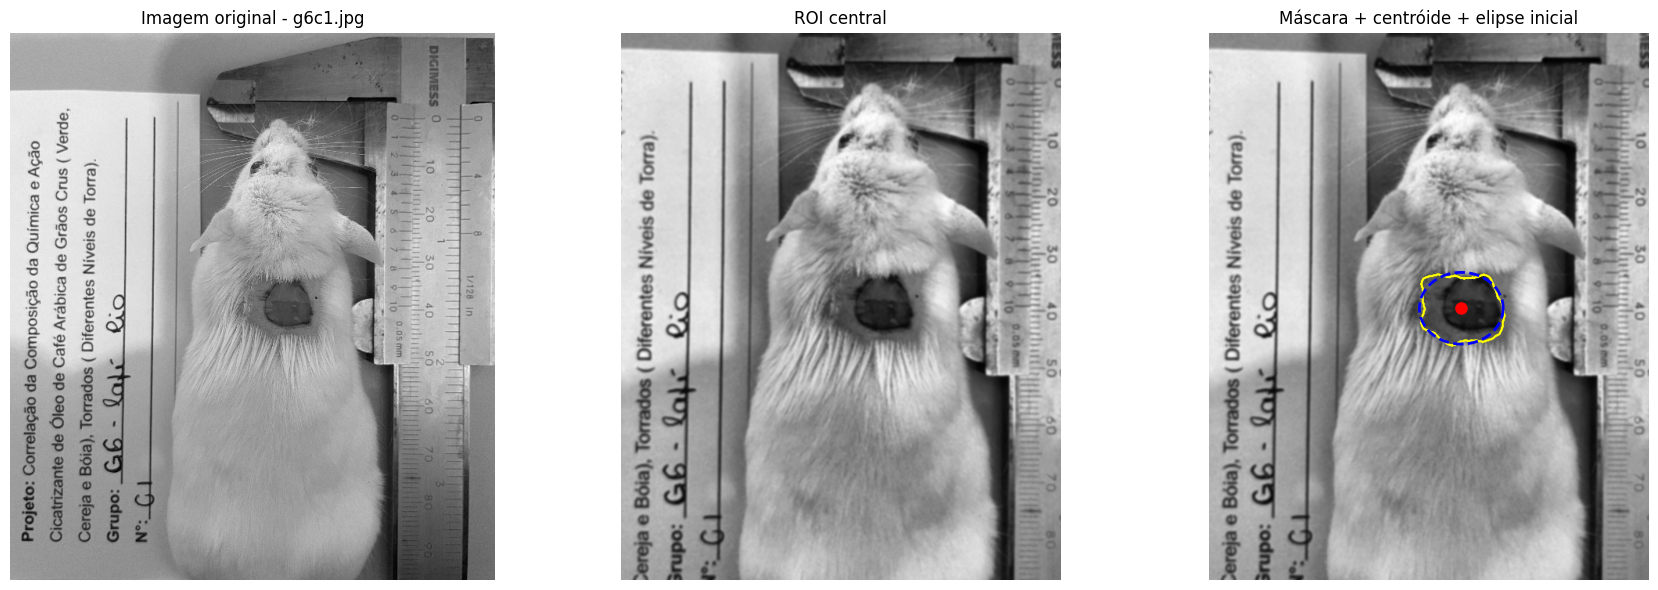

Centróide estimado na ROI: (295.5, 270.4)
Área da região escolhida: 5531.0
Compacidade: 0.738


In [3]:
# =========================================================
# PIPELINE COMPLETO — DETECÇÃO DE LESÃO + CENTRÓIDE + ELIPSE
# =========================================================

!pip install -q opencv-python scikit-image scipy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, measure, morphology

# ==============================
# CONFIGURAÇÃO
# ==============================
nome_arquivo = 'g6c1.jpg'  # <- troque aqui


# ==============================
# 1. LEITURA DA IMAGEM
# ==============================
img = cv2.imread(nome_arquivo, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError(f"Imagem '{nome_arquivo}' não encontrada.")

h0, w0 = img.shape
escala = 700 / max(h0, w0)

if escala < 1:
    img = cv2.resize(img, (int(w0 * escala), int(h0 * escala)))

# ==============================
# 2. PRÉ-PROCESSAMENTO
# ==============================
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_eq = clahe.apply(img)

img_blur = cv2.GaussianBlur(img_eq, (5, 5), 0)

h, w = img_blur.shape
margem_x = int(w * 0.12)
margem_y = int(h * 0.08)

img_roi = img_blur[margem_y:h-margem_y, margem_x:w-margem_x]

# ==============================
# 3. REGIÃO DE BUSCA
# ==============================
h_roi, w_roi = img_roi.shape

yc1 = int(h_roi * 0.30)
yc2 = int(h_roi * 0.78)

xc1 = int(w_roi * 0.20)
xc2 = int(w_roi * 0.78)

busca = img_roi[yc1:yc2, xc1:xc2]

# ==============================
# 4. SEGMENTAÇÃO INICIAL
# ==============================
th = filters.threshold_otsu(busca)

mask = busca < (th * 0.68)

mask = morphology.remove_small_objects(mask, min_size=1800)
mask = morphology.remove_small_holes(mask, area_threshold=1800)
mask = morphology.binary_opening(mask, morphology.disk(8))
mask = morphology.binary_closing(mask, morphology.disk(9))

# ==============================
# 5. ESCOLHA DA REGIÃO
# ==============================
labels = measure.label(mask)
regs = measure.regionprops(labels)

if len(regs) == 0:
    raise ValueError("Nenhuma região detectada.")

centro_ref = np.array([mask.shape[0] / 2, mask.shape[1] / 2])

candidatos = []

for r in regs:
    per = r.perimeter if r.perimeter > 0 else 1
    comp = 4 * np.pi * r.area / (per ** 2)
    dist = np.linalg.norm(np.array(r.centroid) - centro_ref)

    score = dist - 200 * comp
    candidatos.append((score, r))

candidatos.sort(key=lambda x: x[0])
melhor = candidatos[0][1]

# ==============================
# 6. CENTRÓIDE
# ==============================
cy, cx = melhor.centroid

cy_full = cy + yc1
cx_full = cx + xc1

# ==============================
# 7. ELIPSE INICIAL
# ==============================
minr, minc, maxr, maxc = melhor.bbox

ry = (maxr - minr) / 2 * 1.00
rx = (maxc - minc) / 2 * 1.00

t = np.linspace(0, 2 * np.pi, 120)

y_init = cy + ry * np.sin(t)
x_init = cx + rx * np.cos(t)

y_init_full = y_init + yc1
x_init_full = x_init + xc1

# ==============================
# 8. VISUALIZAÇÃO
# ==============================
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title(f'Imagem original - {nome_arquivo}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_roi, cmap='gray')
plt.title('ROI central')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_roi, cmap='gray')

plt.contour(
    mask,
    levels=[0.5],
    colors='yellow',
    origin='image',
    extent=[xc1, xc2, yc2, yc1]
)

plt.plot(cx_full, cy_full, 'ro', markersize=8)
plt.plot(x_init_full, y_init_full, '--b', linewidth=2)

plt.title('Máscara + centróide + elipse inicial')
plt.axis('off')

plt.tight_layout()
plt.show()

# ==============================
# 9. RESULTADOS
# ==============================
print(f'Centróide estimado na ROI: ({cy_full:.1f}, {cx_full:.1f})')
print(f'Área da região escolhida: {melhor.area}')
print(f'Compacidade: {4 * np.pi * melhor.area / (melhor.perimeter ** 2 + 1e-8):.3f}')

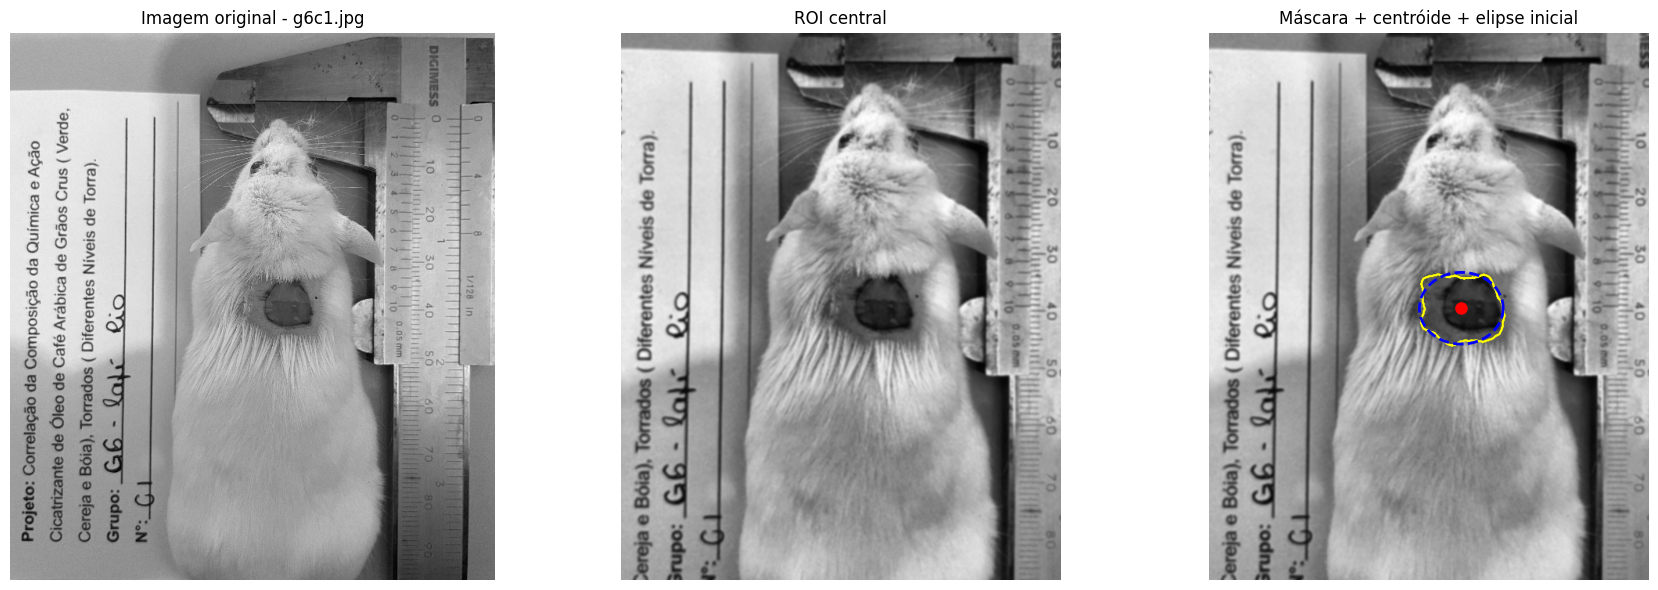

Centróide estimado na ROI: (295.5, 270.4)
Área da região escolhida: 5531.0
Compacidade: 0.738


In [7]:
# =========================================================
# PIPELINE COMPLETO — DETECÇÃO DE LESÃO + CENTRÓIDE + ELIPSE
# =========================================================

!pip install -q opencv-python scikit-image scipy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, measure, morphology

# ==============================
# CONFIGURAÇÃO
# ==============================
nome_arquivo = 'g6c1.jpg'  # <- troque aqui


# ==============================
# 1. LEITURA DA IMAGEM
# ==============================
img = cv2.imread(nome_arquivo, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError(f"Imagem '{nome_arquivo}' não encontrada.")

h0, w0 = img.shape
escala = 700 / max(h0, w0)

if escala < 1:
    img = cv2.resize(img, (int(w0 * escala), int(h0 * escala)))

# ==============================
# 2. PRÉ-PROCESSAMENTO
# ==============================
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_eq = clahe.apply(img)

img_blur = cv2.GaussianBlur(img_eq, (5, 5), 0)

h, w = img_blur.shape
margem_x = int(w * 0.12)
margem_y = int(h * 0.08)

img_roi = img_blur[margem_y:h-margem_y, margem_x:w-margem_x]

# ==============================
# 3. REGIÃO DE BUSCA
# ==============================
h_roi, w_roi = img_roi.shape

yc1 = int(h_roi * 0.30)
yc2 = int(h_roi * 0.78)

xc1 = int(w_roi * 0.20)
xc2 = int(w_roi * 0.78)

busca = img_roi[yc1:yc2, xc1:xc2]

# ==============================
# 4. SEGMENTAÇÃO INICIAL
# ==============================
th = filters.threshold_otsu(busca)

mask = busca < (th * 0.68)

mask = morphology.remove_small_objects(mask, min_size=1800)
mask = morphology.remove_small_holes(mask, area_threshold=1800)
mask = morphology.binary_opening(mask, morphology.disk(8))
mask = morphology.binary_closing(mask, morphology.disk(9))

# ==============================
# 5. ESCOLHA DA REGIÃO
# ==============================
labels = measure.label(mask)
regs = measure.regionprops(labels)

if len(regs) == 0:
    raise ValueError("Nenhuma região detectada.")

centro_ref = np.array([mask.shape[0] / 2, mask.shape[1] / 2])

candidatos = []

for r in regs:
    per = r.perimeter if r.perimeter > 0 else 1
    comp = 4 * np.pi * r.area / (per ** 2)
    dist = np.linalg.norm(np.array(r.centroid) - centro_ref)

    score = dist - 200 * comp
    candidatos.append((score, r))

candidatos.sort(key=lambda x: x[0])
melhor = candidatos[0][1]

# ==============================
# 6. CENTRÓIDE
# ==============================
cy, cx = melhor.centroid

cy_full = cy + yc1
cx_full = cx + xc1

# ==============================
# 7. ELIPSE INICIAL
# ==============================
minr, minc, maxr, maxc = melhor.bbox

ry = (maxr - minr) / 2 * 1.00
rx = (maxc - minc) / 2 * 1.00

t = np.linspace(0, 2 * np.pi, 120)

y_init = cy + ry * np.sin(t)
x_init = cx + rx * np.cos(t)

y_init_full = y_init + yc1
x_init_full = x_init + xc1

# ==============================
# 8. VISUALIZAÇÃO
# ==============================
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title(f'Imagem original - {nome_arquivo}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_roi, cmap='gray')
plt.title('ROI central')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_roi, cmap='gray')

plt.contour(
    mask,
    levels=[0.5],
    colors='yellow',
    origin='image',
    extent=[xc1, xc2, yc2, yc1]
)

plt.plot(cx_full, cy_full, 'ro', markersize=8)
plt.plot(x_init_full, y_init_full, '--b', linewidth=2)

plt.title('Máscara + centróide + elipse inicial')
plt.axis('off')

plt.tight_layout()
plt.show()

# ==============================
# 9. RESULTADOS
# ==============================
print(f'Centróide estimado na ROI: ({cy_full:.1f}, {cx_full:.1f})')
print(f'Área da região escolhida: {melhor.area}')
print(f'Compacidade: {4 * np.pi * melhor.area / (melhor.perimeter ** 2 + 1e-8):.3f}')

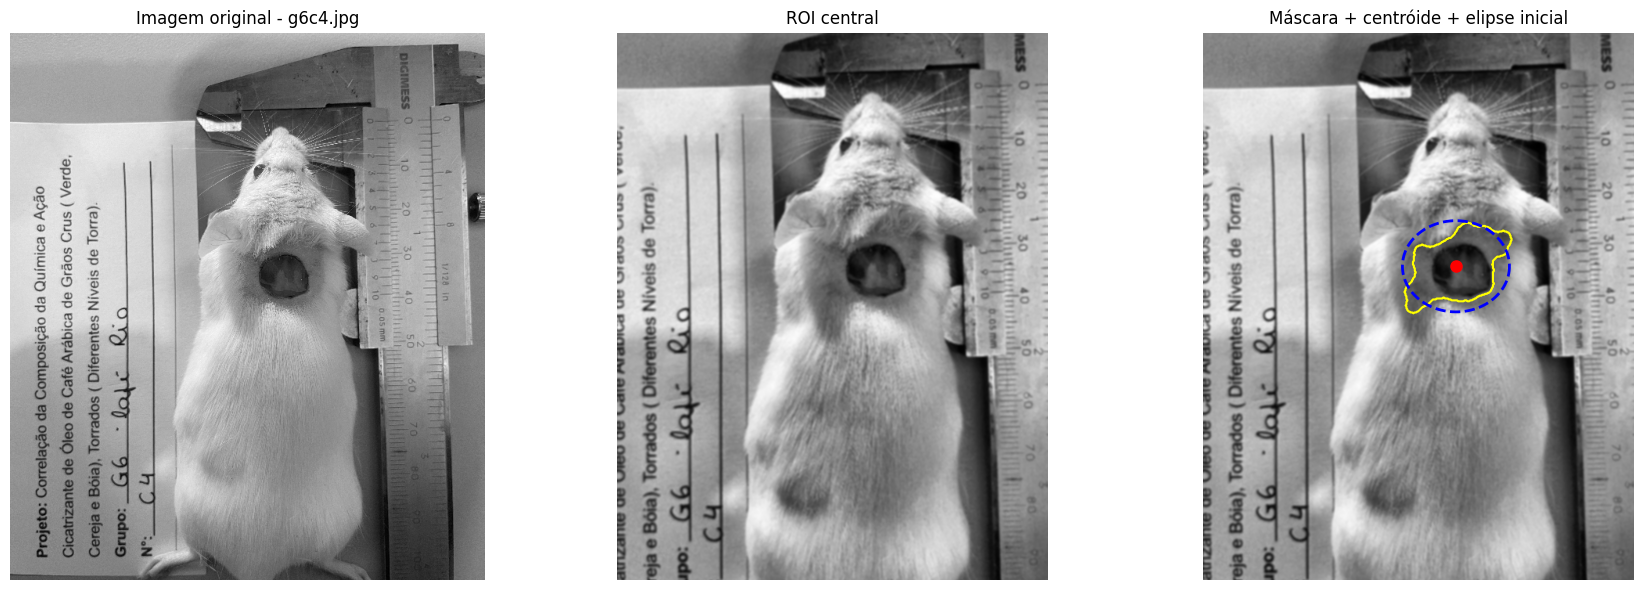

Centróide estimado na ROI: (250.4, 271.2)
Área da região escolhida: 6656.0
Compacidade: 0.572


In [8]:
# =========================================================
# PIPELINE COMPLETO — DETECÇÃO DE LESÃO + CENTRÓIDE + ELIPSE
# =========================================================

!pip install -q opencv-python scikit-image scipy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, measure, morphology

# ==============================
# CONFIGURAÇÃO
# ==============================
nome_arquivo = 'g6c4.jpg'  # <- troque aqui


# ==============================
# 1. LEITURA DA IMAGEM
# ==============================
img = cv2.imread(nome_arquivo, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError(f"Imagem '{nome_arquivo}' não encontrada.")

h0, w0 = img.shape
escala = 700 / max(h0, w0)

if escala < 1:
    img = cv2.resize(img, (int(w0 * escala), int(h0 * escala)))

# ==============================
# 2. PRÉ-PROCESSAMENTO
# ==============================
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_eq = clahe.apply(img)

img_blur = cv2.GaussianBlur(img_eq, (5, 5), 0)

h, w = img_blur.shape
margem_x = int(w * 0.12)
margem_y = int(h * 0.08)

img_roi = img_blur[margem_y:h-margem_y, margem_x:w-margem_x]

# ==============================
# 3. REGIÃO DE BUSCA
# ==============================
h_roi, w_roi = img_roi.shape

yc1 = int(h_roi * 0.30)
yc2 = int(h_roi * 0.78)

xc1 = int(w_roi * 0.20)
xc2 = int(w_roi * 0.78)

busca = img_roi[yc1:yc2, xc1:xc2]

# ==============================
# 4. SEGMENTAÇÃO INICIAL
# ==============================
th = filters.threshold_otsu(busca)

mask = busca < (th * 0.68)

mask = morphology.remove_small_objects(mask, min_size=1800)
mask = morphology.remove_small_holes(mask, area_threshold=1800)
mask = morphology.binary_opening(mask, morphology.disk(8))
mask = morphology.binary_closing(mask, morphology.disk(9))

# ==============================
# 5. ESCOLHA DA REGIÃO
# ==============================
labels = measure.label(mask)
regs = measure.regionprops(labels)

if len(regs) == 0:
    raise ValueError("Nenhuma região detectada.")

centro_ref = np.array([mask.shape[0] / 2, mask.shape[1] / 2])

candidatos = []

for r in regs:
    per = r.perimeter if r.perimeter > 0 else 1
    comp = 4 * np.pi * r.area / (per ** 2)
    dist = np.linalg.norm(np.array(r.centroid) - centro_ref)

    score = dist - 200 * comp
    candidatos.append((score, r))

candidatos.sort(key=lambda x: x[0])
melhor = candidatos[0][1]

# ==============================
# 6. CENTRÓIDE
# ==============================
cy, cx = melhor.centroid

cy_full = cy + yc1
cx_full = cx + xc1

# ==============================
# 7. ELIPSE INICIAL
# ==============================
minr, minc, maxr, maxc = melhor.bbox

ry = (maxr - minr) / 2 * 1.00
rx = (maxc - minc) / 2 * 1.00

t = np.linspace(0, 2 * np.pi, 120)

y_init = cy + ry * np.sin(t)
x_init = cx + rx * np.cos(t)

y_init_full = y_init + yc1
x_init_full = x_init + xc1

# ==============================
# 8. VISUALIZAÇÃO
# ==============================
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title(f'Imagem original - {nome_arquivo}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_roi, cmap='gray')
plt.title('ROI central')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_roi, cmap='gray')

plt.contour(
    mask,
    levels=[0.5],
    colors='yellow',
    origin='image',
    extent=[xc1, xc2, yc2, yc1]
)

plt.plot(cx_full, cy_full, 'ro', markersize=8)
plt.plot(x_init_full, y_init_full, '--b', linewidth=2)

plt.title('Máscara + centróide + elipse inicial')
plt.axis('off')

plt.tight_layout()
plt.show()

# ==============================
# 9. RESULTADOS
# ==============================
print(f'Centróide estimado na ROI: ({cy_full:.1f}, {cx_full:.1f})')
print(f'Área da região escolhida: {melhor.area}')
print(f'Compacidade: {4 * np.pi * melhor.area / (melhor.perimeter ** 2 + 1e-8):.3f}')